In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# We use '../' to go up one folder level from 'notebooks/' into 'data/raw/'
file_path = '../data/raw/News_Category_Dataset_v3.json'

# This dataset is formatted as JSON Lines, so we use lines=True
df = pd.read_json(file_path, lines=True)

# Display basic info
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())

Dataset contains 209527 rows and 6 columns.


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


Dataset size after filtering: 66137 rows.


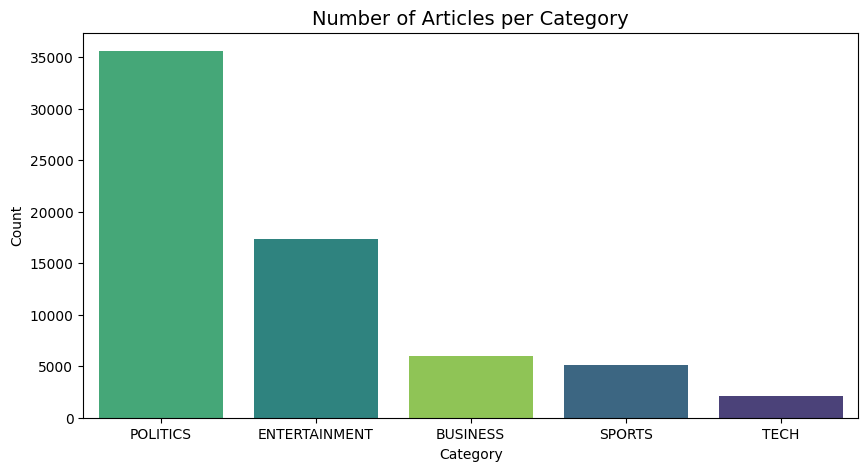

In [2]:
# The dataset has categories in ALL CAPS. Let's pick 5 distinct ones.
target_categories = ['POLITICS', 'ENTERTAINMENT', 'BUSINESS', 'SPORTS', 'TECH']

# Filter our dataframe to ONLY include these 5 categories
df_filtered = df[df['category'].isin(target_categories)].copy()

print(f"Dataset size after filtering: {df_filtered.shape[0]} rows.")

# Plot the distribution
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_filtered, 
    x='category',
    hue='category',
    order=df_filtered['category'].value_counts().index,
    palette='viridis',
    legend=False
)
plt.title('Number of Articles per Category', fontsize=14)
plt.ylabel('Count')
plt.xlabel('Category')
plt.show()

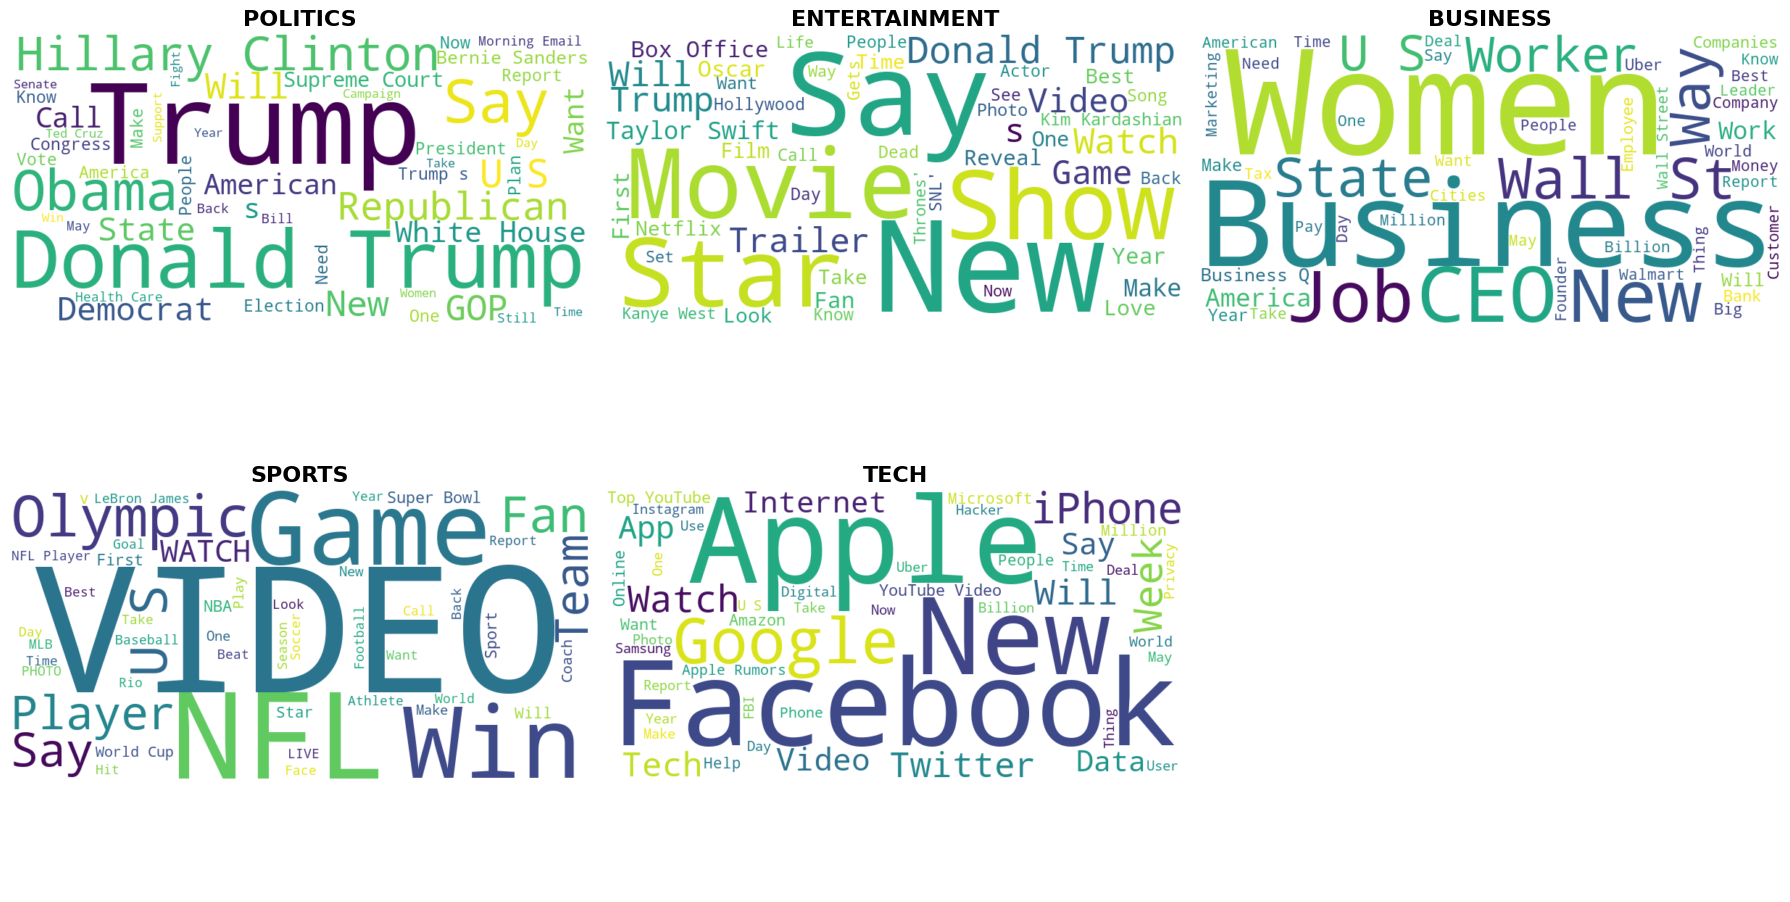

In [3]:
from wordcloud import WordCloud

# Set up a 2x3 grid for our 5 word clouds
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, category in enumerate(target_categories):
    # Combine all headlines for the specific category into one giant text string
    text = " ".join(headline for headline in df_filtered[df_filtered['category'] == category]['headline'])
    
    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(text)
    
    # Plot it in the grid
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(category, fontsize=16, fontweight='bold')
    axes[i].axis('off')

# Hide the 6th empty subplot (since we only have 5 categories)
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import spacy
import re

# 1. Encode the Target Labels (Convert 'POLITICS' to 0, 'SPORTS' to 1, etc.)
encoder = LabelEncoder()
df_filtered['label'] = encoder.fit_transform(df_filtered['category'])

# 2. The Train/Test Split (80% Train, 20% Test)
# We use stratify=df_filtered['label'] to ensure the imbalanced categories are split evenly
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['headline'], 
    df_filtered['label'], 
    test_size=0.20, 
    random_state=42,
    stratify=df_filtered['label'] 
)

print(f"Training set size: {X_train.shape[0]} headlines")
print(f"Testing set size: {X_test.shape[0]} headlines")

# 3. Load spaCy for text cleaning
# We disable NER and parser to make it run much faster, as we only need tokenization and stopwords
nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

# 4. Create our rigorous cleaning function
def clean_text(text):
    # Lowercase and remove punctuation/numbers using Regex
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Process with spaCy to remove stopwords and lemmatize
    doc = nlp(text)
    clean_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.text.strip()]
    
    return " ".join(clean_tokens)

print("\nStarting text cleaning (this might take a minute or two depending on your CPU)...")

# Apply cleaning to Train and Test INDEPENDENTLY
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

print("Text cleaning complete!")

# Let's look at the before and after for the first training example
print("\n--- Before Cleaning ---")
print(X_train.iloc[0])
print("\n--- After Cleaning ---")
print(X_train_clean.iloc[0])

Training set size: 52909 headlines
Testing set size: 13228 headlines

Starting text cleaning (this might take a minute or two depending on your CPU)...
Text cleaning complete!

--- Before Cleaning ---
Trump Takes Off To Mar-A-Lago After National Emergency Declaration

--- After Cleaning ---
trump take maralago national emergency declaration


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize TF-IDF Vectorizer
# We limit to the top 10,000 words to keep the model fast and avoid memory crashes
tfidf = TfidfVectorizer(max_features=10000)

print("Vectorizing text data...")
# Fit ONLY on the training data, then transform both
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print(f"Training data shape after TF-IDF: {X_train_tfidf.shape}")

# 2. Initialize and Train our Baseline Model: Logistic Regression
# max_iter=1000 ensures the algorithm has enough time to find the optimal weights
log_reg = LogisticRegression(max_iter=1000, random_state=42)

print("Training Logistic Regression baseline...")
log_reg.fit(X_train_tfidf, y_train)

# 3. Make Predictions on the Test Set
y_pred_base = log_reg.predict(X_test_tfidf)

# 4. Evaluate the Results
acc_base = accuracy_score(y_test, y_pred_base)

print(f"\n--- Baseline Model Results ---")
print(f"Accuracy: {acc_base * 100:.2f}%\n")

# The classification report shows Precision, Recall, and F1-score for each category
# We use encoder.classes_ to automatically map the 0,1,2,3,4 labels back to their text names
print("Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=encoder.classes_))

Vectorizing text data...
Training data shape after TF-IDF: (52909, 10000)
Training Logistic Regression baseline...

--- Baseline Model Results ---
Accuracy: 86.05%

Classification Report:
               precision    recall  f1-score   support

     BUSINESS       0.76      0.56      0.65      1198
ENTERTAINMENT       0.87      0.88      0.87      3473
     POLITICS       0.87      0.95      0.91      7121
       SPORTS       0.89      0.70      0.78      1015
         TECH       0.83      0.44      0.58       421

     accuracy                           0.86     13228
    macro avg       0.84      0.71      0.76     13228
 weighted avg       0.86      0.86      0.85     13228



In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. Prepare Text for Deep Learning ---
print("Tokenizing and padding text for LSTM...")

# Initialize Tokenizer (Keep top 10,000 words, replace unknown words with <OOV>)
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_clean)

# Convert words to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

# Pad sequences so they are all exactly 50 words long (headlines are short)
max_length = 50
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# --- 2. Load GloVe Embeddings ---
print("Loading GloVe 100d vectors (this takes a few seconds)...")
embeddings_index = {}
glove_path = '../data/raw/glove.6B.100d.txt'

# Read the GloVe file line by line
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} word vectors.")

# --- 3. Create the Embedding Matrix ---
word_index = tokenizer.word_index
# We add 1 to vocab size for the <OOV> token
vocab_size = min(10000, len(word_index)) + 1 
embedding_matrix = np.zeros((vocab_size, 100)) # 100 because we downloaded 100d

# Map our dataset's words to GloVe's mathematical vectors
for word, i in word_index.items():
    if i >= 10000:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# --- 4. Build the LSTM Architecture ---
print("Building the LSTM Model...")
model = Sequential([
    # The Embedding layer uses our GloVe matrix. trainable=False means we don't change GloVe's weights
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=max_length, trainable=False),
    # Dropout prevents overfitting by randomly turning off 20% of neurons
    SpatialDropout1D(0.2),
    # The LSTM layer with 64 units
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    # Output layer: 5 neurons (for 5 categories) using 'softmax' to get probabilities
    Dense(5, activation='softmax')
])

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# --- 5. Train the Model ---
print("\nStarting training... (This may take a few minutes depending on your CPU/GPU)")

# EarlyStopping stops training if the model stops improving, preventing overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train for up to 15 epochs
history = model.fit(
    X_train_padded, y_train, 
    epochs=15, 
    batch_size=64, 
    validation_data=(X_test_padded, y_test),
    callbacks=[early_stop],
    verbose=1
)

Tokenizing and padding text for LSTM...
Loading GloVe 100d vectors (this takes a few seconds)...
Loaded 400000 word vectors.
Building the LSTM Model...


C:\Data_Science\news_classification_project\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │       1,000,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,000,100 (3.82 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,100 (3.82 MB)


Starting training... (This may take a few minutes depending on your CPU/GPU)
Epoch 1/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.6796 - loss: 0.9370 - val_accuracy: 0.7198 - val_loss: 0.7915
Epoch 2/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.7168 - loss: 0.8306 - val_accuracy: 0.7548 - val_loss: 0.7317
Epoch 3/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.7317 - loss: 0.7661 - val_accuracy: 0.7579 - val_loss: 0.6976
Epoch 4/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 86s 56ms/step - accuracy: 0.7482 - loss: 0.6933 - val_accuracy: 0.8056 - val_loss: 0.5569
Epoch 5/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.7889 - loss: 0.5886 - val_accuracy: 0.8256 - val_loss: 0.4995
Epoch 6/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.8053 - loss: 0.5470 - val_accuracy: 0.8302 - val_loss: 0.4835
Epoch 7/15
827/827 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.8130 - loss: 0.5255 - val_accuracy: 0.8420 - val_loss: 0.4540
Epoch 8/15
8

Generating predictions...
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step


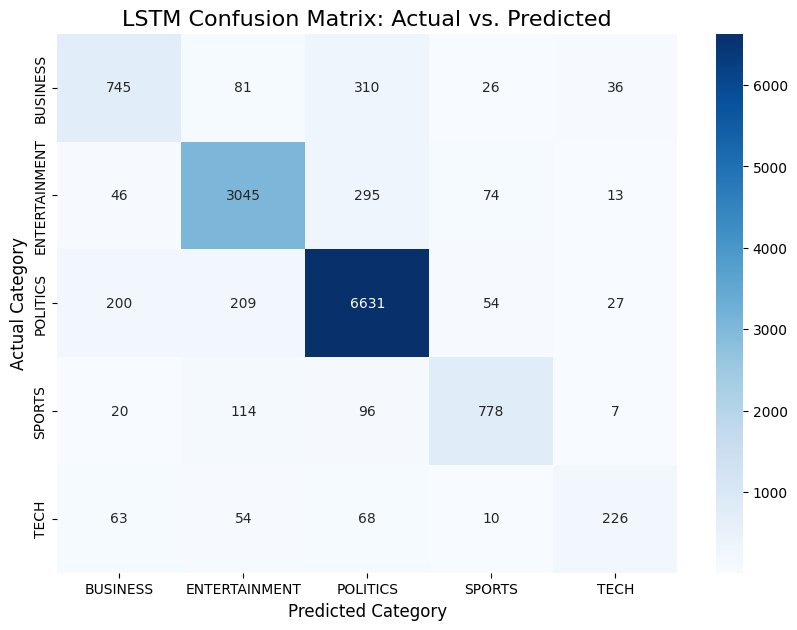


Total misclassified headlines: 1803 out of 13228

--- Let's look at 5 specific examples the model got wrong ---


,Headline,Actual,Predicted
6095,What Happens To Kids Who Accidentally Shoot Their Siblings,POLITICS,ENTERTAINMENT
4536,Building up Trust,POLITICS,BUSINESS
11512,How to Really Listen in a Difficult Conversation (6.2),BUSINESS,ENTERTAINMENT
1176,Ice-T Reveals What It Was Like To Have Vice President Joe Biden On The 'SVU' Set,ENTERTAINMENT,POLITICS
4376,What Would the Last 50 Years Look Like Without Rapidly Growing Inequality?,POLITICS,BUSINESS


In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Get LSTM Predictions
print("Generating predictions...")
# The LSTM outputs a list of 5 probabilities for each headline. 
# np.argmax picks the index (0-4) with the highest probability.
y_pred_prob = model.predict(X_test_padded)
y_pred_lstm = np.argmax(y_pred_prob, axis=1)

# 2. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(10, 7))
# We use encoder.classes_ to label the axes with actual category names instead of 0,1,2,3,4
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('LSTM Confusion Matrix: Actual vs. Predicted', fontsize=16)
plt.ylabel('Actual Category', fontsize=12)
plt.xlabel('Predicted Category', fontsize=12)
plt.show()

# 3. Error Analysis: Finding the Failure Cases
# Let's map the numerical labels back to text for easy reading
actual_categories = encoder.inverse_transform(y_test)
predicted_categories = encoder.inverse_transform(y_pred_lstm)

# Create a DataFrame of just the test set to compare
results_df = pd.DataFrame({
    'Headline': X_test.values,
    'Actual': actual_categories,
    'Predicted': predicted_categories
})

# Filter for only the rows where the model guessed wrong
errors_df = results_df[results_df['Actual'] != results_df['Predicted']]

print(f"\nTotal misclassified headlines: {len(errors_df)} out of {len(X_test)}")
print("\n--- Let's look at 5 specific examples the model got wrong ---")

# Increase pandas column width so we can read the whole headline
pd.set_option('display.max_colwidth', None)
display(errors_df.sample(5, random_state=42))

In [8]:
import joblib
import os

# Ensure the models directory exists (we just made it in the terminal, but good practice)
os.makedirs('../models', exist_ok=True)

# Save the Baseline Champion (Logistic Regression)
joblib.dump(log_reg, '../models/logistic_regression_model.pkl')

# Save the TF-IDF Vectorizer (so the app knows your exact 10,000 word vocabulary)
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

# Save the Label Encoder (so the app can translate '0' back to 'POLITICS')
joblib.dump(encoder, '../models/label_encoder.pkl')

print("Models successfully saved to the /models directory!")

Models successfully saved to the /models directory!
